# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Yogi Ramadhani
- **Email:** ramadhaniiyogi@gmail.com
- **ID Dicoding:** CDCC284D6Y2231

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda (cnt) pada hari kerja selama tahun 2012, dan seberapa besar penurunannya pada kondisi cuaca buruk dibandingkan cuaca cerah?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda (cnt) pada hari kerja selama musim panas (summer) tahun 2012, dan berapa rata-rata jumlah penyewaan pada jam tersebut?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt


## Data Wrangling

### Gathering Data

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


#### Load df ...

In [3]:
hour_path = "/content/drive/MyDrive/Bike-sharing-dataset/hour.csv"
day_path  = "/content/drive/MyDrive/Bike-sharing-dataset/day.csv"

df_hour = pd.read_csv(hour_path)
df_day  = pd.read_csv(day_path)

In [4]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua bagian: df_hour (per jam) dan df_day (per hari).
- Kedua dataset memiliki fitur yang serupa, seperti waktu, cuaca, suhu, kelembapan, dan jumlah penyewaan (casual, registered, cnt).
- df_hour digunakan untuk analisis detail pola penggunaan dalam sehari.
- df_day digunakan untuk melihat tren secara umum dalam jangka waktu yang lebih luas.

### Assessing Data

####Cek Struktur Data

In [6]:
df_hour.info()
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

**Steps to Take:**
- Menampilkan informasi umum dataset seperti jumlah baris dan kolom
- Mengidentifikasi tipe data pada setiap kolom
- Memastikan setiap fitur memiliki tipe data yang sesuai untuk analisis

**Insight:**
- Dataset df_hour memiliki jumlah data yang lebih besar karena berbasis per jam
- Dataset df_day lebih ringkas karena merupakan agregasi harian
- Tidak terdapat missing value karena seluruh kolom memiliki jumlah non-null yang lengkap
- Tipe data pada kolom dteday masih berupa object sehingga perlu dikonversi ke datetime pada tahap cleaning

####Cek Missing Value

In [7]:
df_hour.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [8]:
df_day.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Steps to Take:**
- Menghitung jumlah missing value pada setiap kolom di dataset df_hour dan df_day
- Mengidentifikasi apakah terdapat nilai kosong (null) yang dapat memengaruhi analisis
- Memastikan setiap fitur memiliki data yang lengkap sebelum masuk ke tahap berikutnya

**Insight:**
- Tidak ditemukan missing value pada kedua dataset
- Hal ini menunjukkan bahwa dataset sudah dalam kondisi lengkap dan tidak memerlukan penanganan khusus seperti imputasi atau penghapusan data
- Dataset siap digunakan untuk tahap analisis tanpa perlu proses cleaning terkait missing value

####Cek Duplicate Data

In [9]:
df_hour.duplicated().sum()

np.int64(0)

In [10]:
df_day.duplicated().sum()

np.int64(0)

**Steps to Take:**
- Menghitung jumlah data duplikat pada dataset df_hour dan df_day
- Mengidentifikasi apakah terdapat baris data yang sama persis (duplicate)
- Menentukan apakah data duplikat perlu dihapus untuk menghindari bias dalam analisis

**Insight:**
- Tidak ditemukan data duplikat pada kedua dataset
- Hal ini menunjukkan bahwa dataset sudah bersih dari redundansi data
- Seluruh data bersifat unik sehingga tidak diperlukan proses penghapusan duplikat pada tahap cleaning

####Cek Validitas Nilai

In [11]:
df_hour['hr'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [12]:
df_hour['season'].unique()

array([1, 2, 3, 4])

In [13]:
df_hour['weathersit'].unique()

array([1, 2, 3, 4])

In [14]:
df_day['season'].unique()

array([1, 2, 3, 4])

In [15]:
df_hour['weathersit'].unique()

array([1, 2, 3, 4])

In [16]:
df_hour['yr'].unique()

array([0, 1])

**Steps to Take:**
- Mengecek nilai unik pada kolom-kolom kategorikal dan waktu (hr, season, weathersit, yr)
- Membandingkan nilai yang muncul dengan definisi dataset
- Memastikan semua nilai berada dalam rentang yang valid
- Mengidentifikasi apakah terdapat nilai yang tidak sesuai (invalid value)

**Insight:**
- Kolom hr memiliki nilai 0–23 → valid sesuai representasi jam dalam sehari
- Kolom season memiliki nilai 1–4 → sesuai dengan 4 kategori musim
- Kolom weathersit memiliki nilai 1–4 → sesuai dengan kategori kondisi cuaca
- Kolom yr memiliki nilai 0 dan 1 → merepresentasikan tahun 2011 dan 2012
- Tidak ditemukan nilai di luar rentang yang seharusnya, sehingga tidak terdapat invalid value pada dataset

####Cek Outlier

In [17]:
Q1_hour = df_hour['cnt'].quantile(0.25)
Q3_hour = df_hour['cnt'].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

lower_hour = Q1_hour - 1.5 * IQR_hour
upper_hour = Q3_hour + 1.5 * IQR_hour

print("Lower Bound (hour):", lower_hour)
print("Upper Bound (hour):", upper_hour)

outliers_hour = df_hour[
    (df_hour['cnt'] < lower_hour) |
    (df_hour['cnt'] > upper_hour)
]

print("Jumlah outlier (hour):", len(outliers_hour))
outliers_hour.head()

Lower Bound (hour): -321.5
Upper Bound (hour): 642.5
Jumlah outlier (hour): 505


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
5536,5537,2011-08-23,3,0,8,14,0,2,1,1,0.72,0.6515,0.30,0.0896,149,502,651
10358,10359,2012-03-12,1,1,3,17,0,1,1,2,0.62,0.6212,0.38,0.4179,87,557,644
10359,10360,2012-03-12,1,1,3,18,0,1,1,2,0.60,0.6212,0.43,0.1940,89,623,712
10382,10383,2012-03-13,1,1,3,17,0,2,1,1,0.70,0.6364,0.37,0.1045,62,614,676
10383,10384,2012-03-13,1,1,3,18,0,2,1,1,0.70,0.6364,0.34,0.2985,96,638,734


In [18]:
Q1_day = df_day['cnt'].quantile(0.25)
Q3_day = df_day['cnt'].quantile(0.75)
IQR_day = Q3_day - Q1_day

lower_day = Q1_day - 1.5 * IQR_day
upper_day = Q3_day + 1.5 * IQR_day

print("Lower Bound (day):", lower_day)
print("Upper Bound (day):", upper_day)

outliers_day = df_day[
    (df_day['cnt'] < lower_day) |
    (df_day['cnt'] > upper_day)
]

print("Jumlah outlier (day):", len(outliers_day))
outliers_day.head()

Lower Bound (day): -1054.0
Upper Bound (day): 10162.0
Jumlah outlier (day): 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


**Steps to Take:**
- Menghitung kuartil pertama (Q1) dan kuartil ketiga (Q3) dari variabel cnt
- Menghitung Interquartile Range (IQR) sebagai selisih Q3 dan Q1
- Menentukan batas bawah dan batas atas menggunakan rumus IQR
- Mengidentifikasi data yang berada di luar batas tersebut sebagai outlier

**Insight:** df_hour
- Ditemukan 505 outlier pada dataset per jam
- Hal ini menunjukkan bahwa data per jam memiliki variasi yang tinggi
- Outlier kemungkinan disebabkan oleh lonjakan pengguna pada jam tertentu, event tertentu, kondisi cuaca atau waktu khusus

**Insight:** df_day
- Tidak ditemukan outlier
- Menunjukkan bahwa data harian lebih stabil dan tidak memiliki nilai ekstrem
- Agregasi harian membuat distribusi data lebih “smooth”

### Cleaning Data

#### Fixing data type problem

In [19]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_day['dteday']  = pd.to_datetime(df_day['dteday'])

**Insight:**
- Kolom dteday pada kedua dataset awalnya bertipe object (string) sehingga belum optimal untuk analisis berbasis waktu
- Konversi ke tipe datetime membuat data lebih terstruktur dan mudah digunakan dalam analisis temporal
- Perubahan ini memungkinkan eksplorasi pola waktu seperti tren harian, bulanan, maupun musiman
- Selain itu, transformaasi ini juga mendukung penggunaan fungsi time-series di pandas seperti filtering berdasarkan tanggal dan ekstraksi informasi waktu (bulan, hari, tahun)

#### Fixing outlier problem

In [20]:
outlier_idx_hour = df_hour[
    (df_hour['cnt'] < lower_hour) |
    (df_hour['cnt'] > upper_hour)
].index

df_hour_clean = df_hour.drop(outlier_idx_hour)

In [21]:
print("Hour sebelum:", df_hour.shape[0])
print("Hour sesudah:", df_hour_clean.shape[0])

Hour sebelum: 17379
Hour sesudah: 16874


**Insight:**
- Sebanyak 505 data outlier berhasil dihapus dari dataset df_hour, sehingga jumlah data berkurang dari 17.379 menjadi 16.874
- Penghapusan ini dilakukan untuk mengurangi pengaruh nilai ekstrem yang dapat mengganggu analisis pola umum
- Dengan menghapus outlier, distribusi data menjadi lebih stabil dan representatif untuk analisis eksploratif (EDA)

## Exploratory Data Analysis (EDA)

### Explore pertanyaan bisnis 1

In [22]:
df_q1 = df_day[
    (df_day['workingday'] == 1) &
    (df_day['yr'] == 1)
]

In [23]:
weather_avg = df_q1.groupby('weathersit')['cnt'].mean()
weather_avg

,cnt
weathersit,
1,6190.275000
2,5064.367816
3,1700.666667


In [24]:
clear = weather_avg[1]
bad   = weather_avg[3]

penurunan = ((clear - bad) / clear) * 100
print(f"Penurunan dari cuaca cerah ke buruk: {penurunan:.2f}%")

Penurunan dari cuaca cerah ke buruk: 72.53%


**Insight:**
- Hasil analisis menunjukkan bahwa rata-rata jumlah penyewaan sepeda berbeda secara signifikan pada setiap kondisi cuaca. Pada kondisi cuaca cerah (weathersit = 1), rata-rata penyewaan mencapai sekitar 6190 unit, kemudian menurun pada kondisi berawan (weathersit = 2) menjadi sekitar 5064 unit, dan turun drastis pada kondisi cuaca buruk (weathersit = 3) menjadi sekitar 1700 unit.

- Perhitungan lebih lanjut menunjukkan bahwa terjadi penurunan sebesar 72.53% dari kondisi cuaca cerah ke kondisi cuaca buruk, yang mengindikasikan adanya hubungan kuat antara kondisi cuaca dan jumlah penyewaan sepeda.

####Explore pertanyaan bisnis 2

In [25]:
df_q2 = df_hour_clean[
    (df_hour_clean['workingday'] == 1) &
    (df_hour_clean['yr'] == 1) &
    (df_hour_clean['season'] == 2)
]

In [26]:
hourly_avg_summer = df_q2.groupby('hr')['cnt'].mean()
hourly_avg_summer

,cnt
hr,
0,46.046875
1,21.812500
2,10.718750
3,5.714286
4,5.523810
5,28.656250
6,126.218750
7,373.187500
8,558.323529


In [27]:
peak_hour_summer = hourly_avg_summer.idxmax()
peak_value_summer = hourly_avg_summer.max()

print("Jam puncak (summer 2012):", peak_hour_summer)
print("Rata-rata penyewaan:", peak_value_summer)

Jam puncak (summer 2012): 8
Rata-rata penyewaan: 558.3235294117648


**Insight:**
- Hasil analisis menunjukkan bahwa pada hari kerja selama musim panas (summer) tahun 2012, pola penyewaan sepeda mengalami peningkatan signifikan pada pagi hari. Puncak penyewaan terjadi pada jam 08.00 dengan rata-rata sekitar 558 penyewaan, yang merupakan nilai tertinggi dibandingkan jam lainnya

- Pada periode musim panas ini aktivitas penyewaan lebih terkonsentrasi pada pagi hari. Hal ini mengindikasikan bahwa kondisi cuaca yang lebih baik pada pagi hari di musim panas mendorong peningkatan penggunaan sepeda.

- Setelah jam puncak tersebut, jumlah penyewaan cenderung menurun secara bertahap hingga siang hari, sebelum kembali meningkat pada sore hari, namun tidak melebihi puncak pagi

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda (cnt) pada hari kerja selama tahun 2012, dan seberapa besar penurunannya pada kondisi cuaca buruk dibandingkan cuaca cerah?

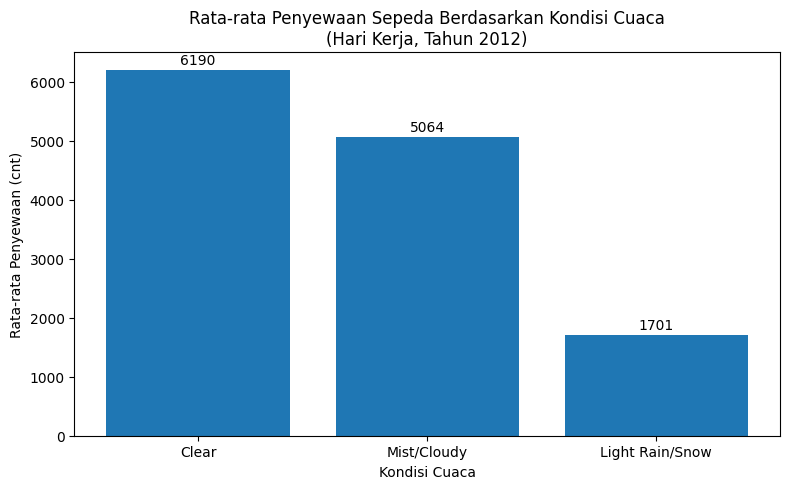

In [28]:
weather_labels = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow"
}

labels = [weather_labels[i] for i in weather_avg.index]
values = weather_avg.values

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50,
             f'{yval:.0f}', ha='center', va='bottom')

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca\n(Hari Kerja, Tahun 2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan (cnt)")

plt.tight_layout()
plt.show()

**Insight:**
- Grafik diatas menceritakan pola yang cukup jelas tentang bagaimana pengguna merespons kondisi cuaca dalam menggunakan sepeda. Pada saat cuaca cerah, jumlah penyewaan berada pada titik tertinggi, mencapai lebih dari 6.000 penyewaan per hari. Hal ini menunjukkan bahwa ketika kondisi lingkungan mendukung tidak hujan, visibilitas baik, dan suhu relatif nyaman, pengguna merasa lebih aman dan nyaman untuk bersepeda.
- Ketika kondisi berubah menjadi berawan atau berkabut, jumlah penyewaan mulai menurun, meskipun tidak terlalu drastis. Ini mengindikasikan bahwa sebagian pengguna masih tetap menggunakan sepeda, kemungkinan karena kebutuhan mobilitas harian seperti berangkat kerja tetap harus dilakukan, meskipun kondisi tidak sepenuhnya ideal.
- Namun, penurunan paling signifikan terjadi saat kondisi cuaca memburuk, seperti hujan ringan atau salju, di mana jumlah penyewaan turun drastis hingga sekitar 1.700 penyewaan. Secara keseluruhan, terjadi penurunan sebesar 72.53% dari kondisi cuaca cerah ke kondisi cuaca buruk, yang menunjukkan dampak yang sangat signifikan dari faktor cuaca terhadap tingkat penggunaan sepeda.
Perubahan ini menunjukkan bahwa mayoritas pengguna memilih untuk tidak menggunakan sepeda ketika kondisi cuaca berpotensi mengganggu kenyamanan dan keselamatan.
- Secara keseluruhan menegaskan bahwa penggunaan sepeda dalam sistem bike sharing sangat bergantung pada kondisi lingkungan, khususnya cuaca. Sepeda lebih banyak digunakan saat kondisi mendukung, dan cenderung ditinggalkan saat risiko atau ketidaknyamanan meningkat.
- Dari sudut pandang bisnis, hal ini memberikan gambaran yang jelas bahwa pengelola layanan perlu bersikap adaptif terhadap kondisi cuaca. Misalnya, meningkatkan kesiapan armada pada hari-hari dengan cuaca baik, serta mengantisipasi penurunan permintaan pada saat cuaca buruk agar operasional tetap efisien.

### Pertanyaan 2: Pada jam berapa terjadi puncak penyewaan sepeda (cnt) pada hari kerja selama musim panas (summer) tahun 2012, dan berapa rata-rata jumlah penyewaan pada jam tersebut?

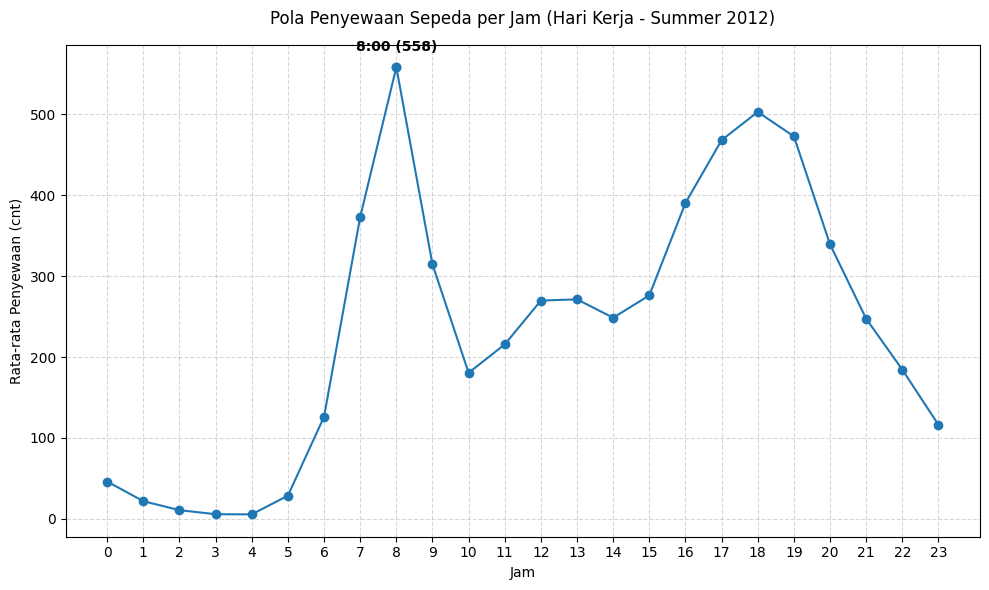

In [29]:
plt.figure(figsize=(10,6))

plt.plot(hourly_avg_summer.index, hourly_avg_summer.values, marker='o')

plt.scatter(peak_hour_summer, peak_value_summer)

plt.text(peak_hour_summer, peak_value_summer + 20,
         f'{peak_hour_summer}:00 ({peak_value_summer:.0f})',
         ha='center', fontsize=10, fontweight='bold')

plt.title("Pola Penyewaan Sepeda per Jam (Hari Kerja - Summer 2012)", pad=15)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(range(0,24))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa pada hari kerja selama musim panas (summer) tahun 2012, pola penyewaan sepeda mengalami pergeseran yang cukup signifikan dibandingkan pola umum. Puncak penyewaan terjadi pada jam 08.00 dengan rata-rata sekitar 558 penyewaan, yang merupakan titik tertinggi sepanjang hari.

- Pola ini menunjukkan bahwa aktivitas penyewaan sepeda sangat terkonsentrasi pada pagi hari, terutama pada jam-jam awal aktivitas kerja. Kenaikan yang tajam sejak pukul 06.00 hingga mencapai puncaknya pada pukul 08.00 mengindikasikan bahwa sepeda banyak dimanfaatkan sebagai sarana transportasi utama untuk berangkat kerja.

- Menariknya, meskipun secara umum penyewaan sepeda sering mencapai puncaknya pada sore hari (jam pulang kerja), pada musim panas justru puncak tertinggi bergeser ke pagi hari. Hal ini kemungkinan disebabkan oleh kondisi suhu yang lebih nyaman di pagi hari, sementara pada siang hingga sore hari suhu cenderung lebih tinggi sehingga mengurangi minat pengguna untuk bersepeda.

- Setelah jam 08.00, jumlah penyewaan menurun secara bertahap hingga siang hari, yang menunjukkan berkurangnya aktivitas mobilitas setelah jam kerja dimulai. Meskipun terdapat peningkatan kembali pada sore hari, tingkat penyewaan tidak mampu melampaui puncak pagi, sehingga memperkuat indikasi adanya perubahan perilaku pengguna yang dipengaruhi oleh faktor musim.

- Temuan ini menunjukkan bahwa faktor musim tidak hanya memengaruhi besarnya permintaan, tetapi juga waktu terjadinya permintaan puncak. Dengan demikian, pengelola layanan dapat menyesuaikan strategi operasional, seperti meningkatkan ketersediaan sepeda pada pagi hari selama musim panas, serta mengoptimalkan redistribusi unit sebelum jam puncak untuk menghindari kekurangan sepeda di titik-titik dengan permintaan tinggi.

## Analisis Lanjutan (Clustering)

- Disini saya menggunakan pendekatan manual grouping dengan mengelompokkan data berdasarkan kategori waktu dalam sehari, yaitu morning, afternoon, evening, dan night. Pengelompokan ini didasarkan pada domain knowledge terkait pola aktivitas manusia, sehingga dapat membantu mengidentifikasi pola penggunaan sepeda secara lebih sederhana dan mudah diinterpretasikan.




In [30]:
def time_category(hr):
    if 5 <= hr < 11:
        return "Morning"
    elif 11 <= hr < 15:
        return "Afternoon"
    elif 15 <= hr < 19:
        return "Evening"
    else:
        return "Night"

In [31]:
df_hour_clean['time_category'] = df_hour_clean['hr'].apply(time_category)
time_cluster = df_hour_clean.groupby('time_category')['cnt'].mean()

In [32]:
time_cluster

,cnt
time_category,
Afternoon,230.107143
Evening,313.394636
Morning,161.016813
Night,105.663326


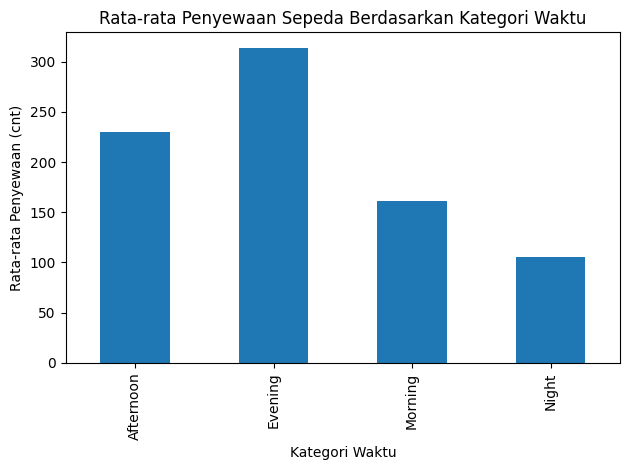

In [33]:
time_cluster.plot(kind='bar')

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kategori Waktu")
plt.xlabel("Kategori Waktu")
plt.ylabel("Rata-rata Penyewaan (cnt)")

plt.tight_layout()
plt.show()

**Insight:**
- Grafik diatas menunjukkan bahwa penggunaan sepeda tidak terdistribusi secara merata sepanjang hari, melainkan terkonsentrasi pada waktu-waktu tertentu. Kategori waktu Evening (sore hari) memiliki rata-rata penyewaan tertinggi, mencapai sekitar 313 penyewaan, yang menunjukkan bahwa periode ini merupakan waktu paling aktif bagi pengguna.

- Tingginya penyewaan pada sore hari kemungkinan besar berkaitan dengan aktivitas pulang kerja, di mana banyak pengguna memanfaatkan sepeda sebagai sarana transportasi harian. Pola ini konsisten dengan perilaku commuting, di mana mobilitas meningkat pada jam-jam tertentu dalam sehari.

- Di sisi lain, kategori Afternoon (siang hari) juga menunjukkan tingkat penyewaan yang cukup tinggi, meskipun tidak setinggi sore hari. Hal ini dapat mengindikasikan adanya aktivitas tambahan di luar jam kerja utama, seperti perjalanan singkat atau keperluan lainnya.

- Sementara itu, kategori Morning (pagi hari) memiliki rata-rata penyewaan yang lebih rendah dibandingkan sore hari, meskipun masih menunjukkan aktivitas yang cukup signifikan. Hal ini menunjukkan bahwa meskipun banyak pengguna menggunakan sepeda untuk berangkat kerja, intensitasnya tidak setinggi saat pulang kerja.

- Kategori Night (malam hari) memiliki jumlah penyewaan terendah, yang menunjukkan bahwa penggunaan sepeda sangat terbatas pada waktu tersebut. Hal ini kemungkinan disebabkan oleh berkurangnya aktivitas masyarakat serta faktor keamanan dan kenyamanan saat malam hari.

- Secara keseluruhan, pola ini menunjukkan bahwa penggunaan sepeda dalam sistem bike sharing sangat dipengaruhi oleh ritme aktivitas harian pengguna, dengan puncak penggunaan terjadi pada sore hari. Oleh karena itu, pengelola layanan dapat mengoptimalkan distribusi sepeda pada periode sore hari untuk memenuhi permintaan yang tinggi, serta mempertimbangkan efisiensi operasional pada malam hari yang memiliki permintaan rendah.

## Conclusion & Recommendation

**Conclusion pertanyaan 1:**
- Berdasarkan hasil analisis, kondisi cuaca memiliki pengaruh yang sangat signifikan terhadap tingkat penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi cuaca cerah, sementara terjadi penurunan yang cukup besar pada kondisi berawan, dan penurunan drastis pada kondisi cuaca buruk seperti hujan ringan atau salju. Pola ini menunjukkan bahwa keputusan pengguna untuk menggunakan sepeda sangat dipengaruhi oleh faktor kenyamanan dan keamanan yang ditentukan oleh kondisi cuaca. Dengan demikian, cuaca dapat dikatakan sebagai faktor eksternal utama yang menentukan fluktuasi permintaan dalam sistem bike sharing.

**Conclusion pertanyaan 2:** xxx
- Berdasarkan analisis, pada hari kerja selama musim panas (summer) tahun 2012, puncak penyewaan sepeda terjadi pada pagi hari, tepatnya pada jam 08.00, dengan rata-rata sekitar 558 penyewaan. Hal ini menunjukkan adanya pergeseran pola penggunaan dibandingkan kondisi umum, di mana puncak biasanya terjadi pada sore hari. Pergeseran ini mengindikasikan bahwa faktor musim, khususnya suhu yang lebih tinggi pada siang hingga sore hari, memengaruhi perilaku pengguna dalam memilih waktu bersepeda. Pengguna cenderung memanfaatkan sepeda pada pagi hari saat kondisi masih nyaman, terutama untuk aktivitas berangkat kerja.Dengan demikian, musim tidak hanya memengaruhi jumlah permintaan, tetapi juga mengubah distribusi waktu penggunaan sepeda dalam sehari.

**Rekomendasi Action Item:**
- Mengoptimalkan ketersediaan sepeda pada kondisi cuaca cerah, karena permintaan terbukti paling tinggi pada kondisi tersebut.
- Mengurangi atau menyesuaikan distribusi sepeda pada kondisi cuaca buruk untuk menghindari kelebihan supply dan meningkatkan efisiensi operasional.
- Memfokuskan distribusi dan kesiapan armada pada jam puncak, khususnya pagi hari (sekitar pukul 08.00) selama musim panas.
- Melakukan redistribusi sepeda (rebalancing) sebelum jam sibuk untuk memastikan ketersediaan unit di lokasi dengan permintaan tinggi.
- Mengembangkan sistem prediksi permintaan berbasis cuaca dan musim untuk mendukung pengambilan keputusan operasional yang lebih proaktif.
- Memberikan insentif atau promosi pada kondisi cuaca kurang ideal atau di luar jam sibuk untuk menjaga tingkat penggunaan tetap stabil.